## Sprint 8 - Proyecto

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

## Paso 4. Análisis exploratorio de datos (Python)

In [4]:
# importar los archivos

df_company = pd.read_csv('project_sql_result_01.csv')
df_trips = pd.read_csv('project_sql_result_04.csv')
df_hipotesis = pd.read_csv("project_sql_result_07.csv")

In [5]:
# estudiar los datos que contienen

print(df_company.head())
print(df_trips.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


In [6]:
print(df_company.info())
print(df_trips.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [7]:
print(df_company.isna().sum())
print(df_trips.isna().sum())

company_name    0
trips_amount    0
dtype: int64
dropoff_location_name    0
average_trips            0
dtype: int64


In [8]:
print(df_company.duplicated().sum())
print(df_trips.duplicated().sum())

0
0


In [9]:
# asegurarte de que los tipos de datos sean correctos

print(df_company.dtypes)
print(df_trips.dtypes)

company_name    object
trips_amount     int64
dtype: object
dropoff_location_name     object
average_trips            float64
dtype: object


In [10]:
# identificar los 10 principales barrios en términos de finalización del recorrido

top_10_destinos = df_trips.sort_values(by="average_trips", ascending=False).head(10)
top_10_destinos

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


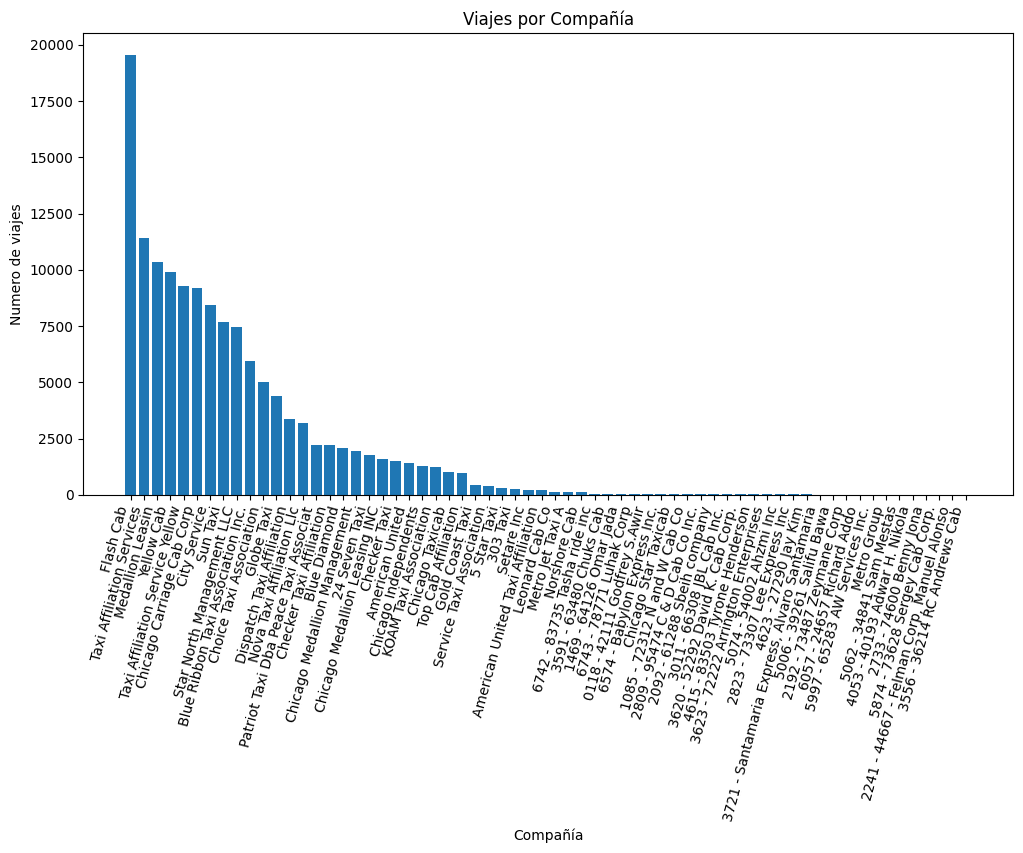

In [11]:
# gráfico empresas de taxis y número de viajes

plt.figure(figsize=(12,6))
plt.bar(df_company["company_name"], df_company["trips_amount"])

plt.xticks(rotation=75, ha='right')
plt.xlabel("Compañía")
plt.ylabel("Numero de viajes")
plt.title("Viajes por Compañía")

plt.show()

Conclusiones: 

- La compañía Flash Cab realiza casi 20,000 viajes, muy por encima del resto. Es claramente la compañía lider del mercado. posiblemente gracias a una mayor flotilla, mejor cobertura, acuerdos comerciales, antigüedad en el mercado.

- Las siguientes 5–7 compañías (desde Taxi Affiliation Services hasta más o menos Sun Taxi) están en el rango de 7,000–12,000 viajes. Compiten en un nivel similar entre ellas.

- La gráfica muestra una curva típica de distribución de Pareto (80/20): Unas pocas empresas concentran la mayoría de los viajes. La mayoría aporta muy poco.

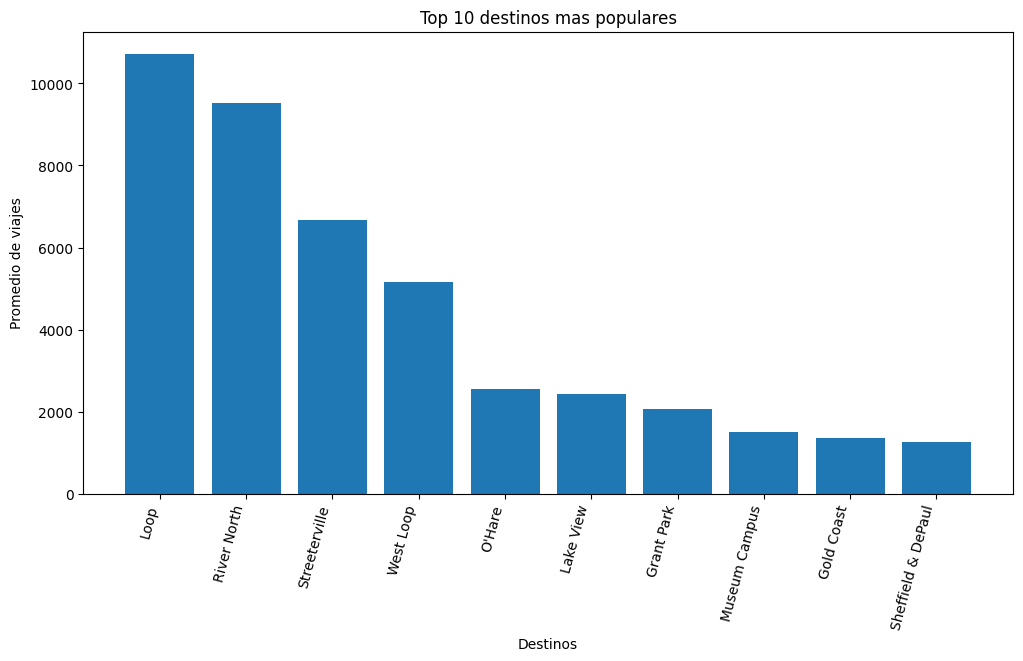

In [12]:
# grafico 10 barrios principales por número de finalizaciones

plt.figure(figsize=(12,6))
plt.bar(top_10_destinos["dropoff_location_name"], top_10_destinos["average_trips"])

plt.xticks(rotation=75, ha='right')
plt.xlabel("Destinos")
plt.ylabel("Promedio de viajes")
plt.title("Top 10 destinos mas populares")

plt.show()

Conclusiones:

- Loop es el destino más popular (casi 11,000 viajes).

- Hay una gran diferencia entre los primeros 4 destinos y el resto.

- Los destinos del centro de Chicago dominan la lista.

## Paso 5. Prueba de hipótesis (Python)

Prueba la hipótesis:
"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

Decide por tu cuenta dónde establecer el nivel de significación (alfa).  

In [13]:
# Convertir start_ts a tipo datetime
df_hipotesis["start_ts"] = pd.to_datetime(df_hipotesis["start_ts"])

# Crear columna con día de la semana (lunes=0, ..., sábado=5, domingo=6)
df_hipotesis["dow"] = df_hipotesis["start_ts"].dt.dayofweek

# Filtrar solo los sábados
df_sat = df_hipotesis[df_hipotesis["dow"] == 5]

# Separar duración de viajes por condición climática
rain = df_sat[df_sat["weather_conditions"] == "Bad"]["duration_seconds"]
good = df_sat[df_sat["weather_conditions"] == "Good"]["duration_seconds"]

print("Tamaño muestra sábados lluviosos  :", len(rain))
print("Tamaño muestra sábados buen clima:", len(good))

# Calcular estadísticas descriptivas
print("\nMedia duración (lluvia)    :", rain.mean())
print("Media duración (buen clima):", good.mean())

# Prueba t de Student para muestras independientes (Welch)
t_stat, p_val = stats.ttest_ind(
    rain,
    good,
    equal_var=False,       
    nan_policy="omit"      
)

print("\nEstadístico t:", t_stat)
print("p-valor      :", p_val)

# Decisión con alfa = 0.05
alpha = 0.05
if p_val < alpha:
    print(f"\nComo p ({p_val:.3e}) < alfa ({alpha}), RECHAZAMOS H0:")
    print("La duración promedio de los viajes los sábados SÍ cambia cuando llueve.")
else:
    print(f"\nComo p ({p_val:.3e}) ≥ alfa ({alpha}), NO rechazamos H0:")
    print("No hay evidencia suficiente de que cambie la duración promedio cuando llueve.")

Tamaño muestra sábados lluviosos  : 180
Tamaño muestra sábados buen clima: 888

Media duración (lluvia)    : 2427.2055555555557
Media duración (buen clima): 1999.6756756756756

Estadístico t: 7.186034288068629
p-valor      : 6.738994326108734e-12

Como p (6.739e-12) < alfa (0.05), RECHAZAMOS H0:
La duración promedio de los viajes los sábados SÍ cambia cuando llueve.


Explica:

- ¿cómo planteaste las hipótesis nula y alternativa?

  Hipotesis nula H₀ = La duración promedio de los viajes los sábados no cambia cuando llueve.

  Hipotesis alternativa H₁ = La duración promedio de los viajes los sábados sí cambia cuando llueve.

- ¿qué criterio usaste para probar las hipótesis y por qué?

  t de Student para muestras independientes (Welch’s t-test) debido a que los datos

  son numéricos y continuos, se comparan dos grupos independientes, tenemos

  tamaños de muestra distintos y asumimos varianzas diferentes.
